In [1]:
# Literacy Analysis Jupyter Notebook
# Author: Hunter H. Davis
# Course: DATS221 - Exploratory Data Analysis

# Setup and Data Import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# process for cleaning joined data
'''df_uncleaned = pd.read_csv(r"C:\Users\hunte\OneDrive\Documents\AMU\Dats221\Week 8\Research Project Data\Joined_Data.csv")
    print(df.columns)
    df.info()
    df.describe()
    print("\nMissing values:")
    print(df.isnull().sum())
# Fill missing PTR values with column medians
df['Primary_PTR'] = df['Primary_PTR'].fillna(df['Primary_PTR'].median())
df['Secondary_PTR'] = df['Secondary_PTR'].fillna(df['Secondary_PTR'].median())
df['Tertiary_PTR'] = df['Tertiary_PTR'].fillna(df['Tertiary_PTR'].median())
    df_cleaned = df.dropna()
    print(df_cleaned)
# Save to a new CSV file
df_cleaned.to_csv('cleaned_data.csv', index=False)'''

In [2]:
# Load cleaned dataset
df = pd.read_csv(r"C:\Users\hunte\OneDrive\Documents\AMU\Dats221\Week 8\Research Project Data\cleaned_data.csv")

In [3]:
# Check basic info and missing values
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 20 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   geoUnit                                                    118 non-null    object 
 1   year                                                       118 non-null    int64  
 2   Total_gov_gdp_spent_on_edu                                 118 non-null    float64
 3   Percent_gdp_spent_upper_secondary_edu                      118 non-null    float64
 4   Percent_gdp_spent_tertiary_edu                             118 non-null    float64
 5   Percent_gdp_spent_secondary_edu                            118 non-null    float64
 6   Literacy rate adult total (% of people ages 15 and above)  118 non-null    float64
 7   Percent_gdp_spent_lower_secondary_edu                      118 non-null    float64
 8   Percent_gd

In [5]:
# Rename column for easier use
df.rename(columns={
    'geoUnit': 'Country',
    'Literacy rate adult total (% of people ages 15 and above)': 'LiteracyRate'
}, inplace=True)

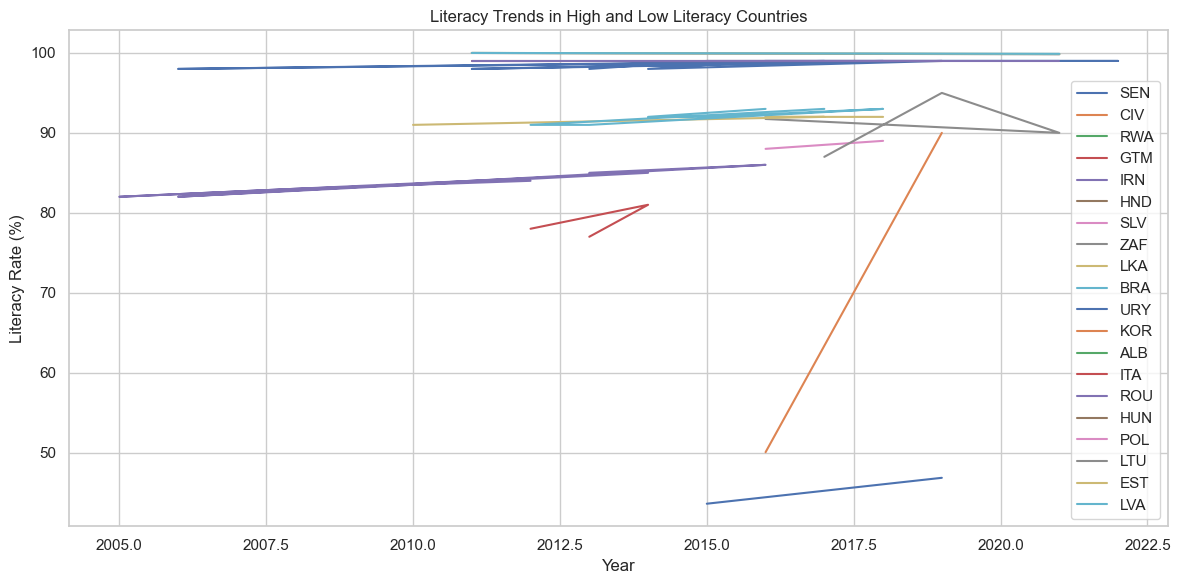

In [53]:
# --- Literacy Rate Over Time for Top/Bottom Countries ---
avg_lit = df.groupby('Country')['LiteracyRate'].mean().sort_values()
low_lit = avg_lit.head(10).index.tolist()
high_lit = avg_lit.tail(10).index.tolist()

plt.figure(figsize=(12, 6))
for country in low_lit + high_lit:
    subset = df[df['Country'] == country]
    plt.plot(subset['year'], subset['LiteracyRate'], label=country)
plt.title('Literacy Trends in High and Low Literacy Countries')
plt.xlabel('Year')
plt.ylabel('Literacy Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

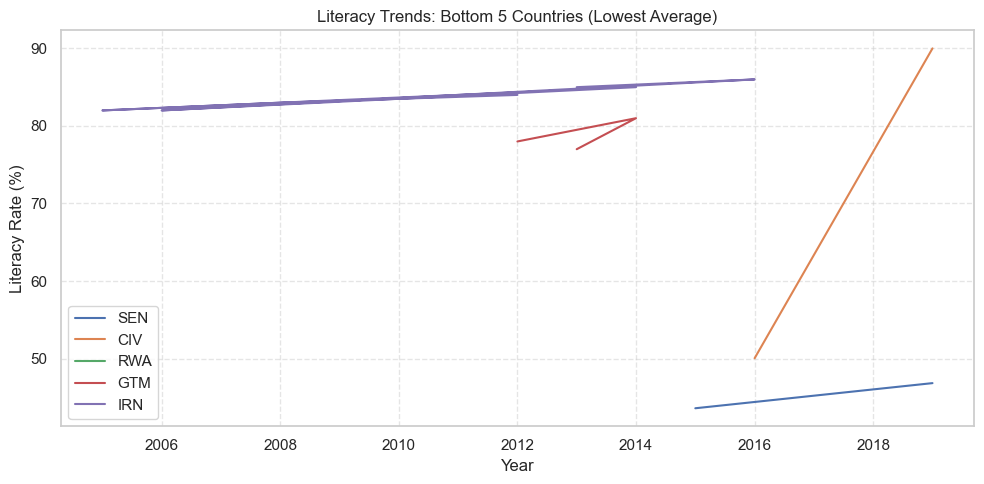

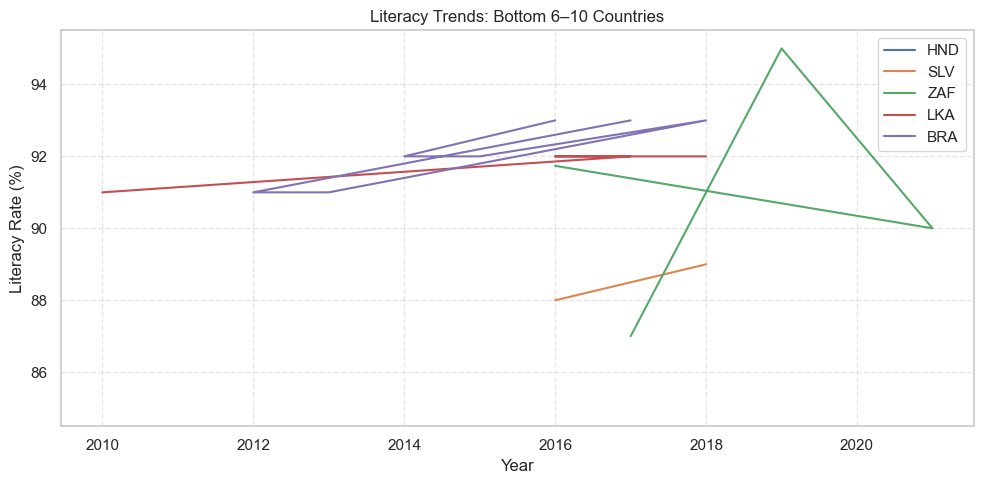

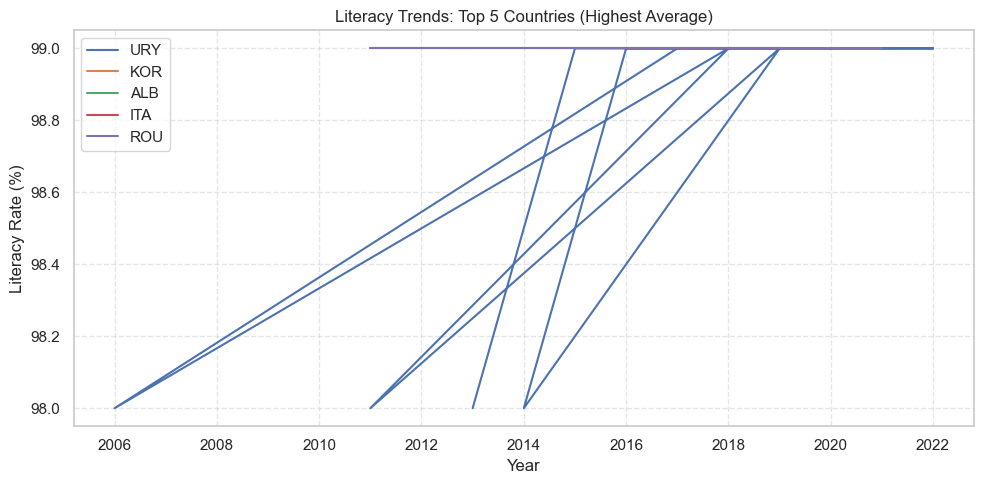

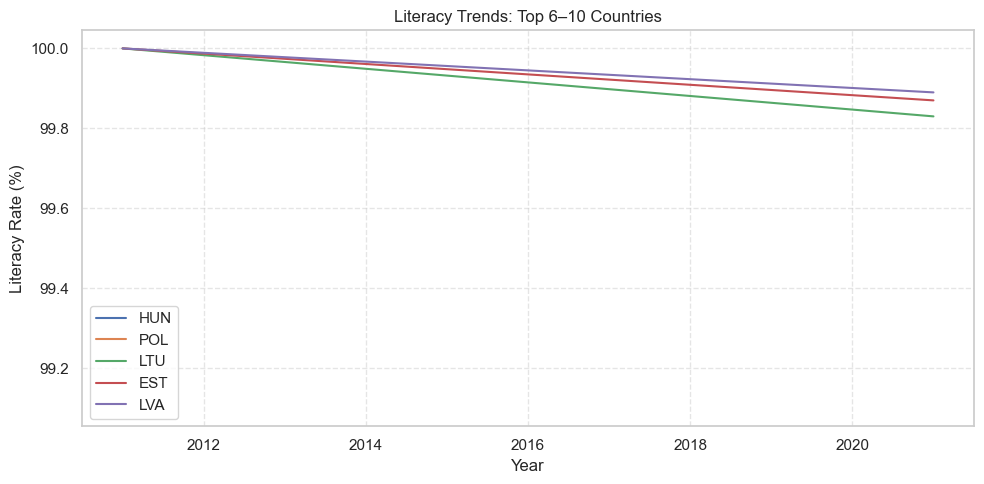

In [55]:
# Compute average literacy per country
avg_lit = df.groupby('Country')['LiteracyRate'].mean().sort_values()
low_lit = avg_lit.head(10).index.tolist()
high_lit = avg_lit.tail(10).index.tolist()

# Split into subgroups
low_lit_1 = low_lit[:5]
low_lit_2 = low_lit[5:]
high_lit_1 = high_lit[:5]
high_lit_2 = high_lit[5:]

# Function to create each plot
def plot_trends(country_list, title):
    plt.figure(figsize=(10, 5))
    for country in country_list:
        subset = df[df['Country'] == country]
        plt.plot(subset['year'], subset['LiteracyRate'], label=country)
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Literacy Rate (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Generate the four separate plots
plot_trends(low_lit_1, 'Literacy Trends: Bottom 5 Countries (Lowest Average)')
plot_trends(low_lit_2, 'Literacy Trends: Bottom 6–10 Countries')
plot_trends(high_lit_1, 'Literacy Trends: Top 5 Countries (Highest Average)')
plot_trends(high_lit_2, 'Literacy Trends: Top 6–10 Countries')

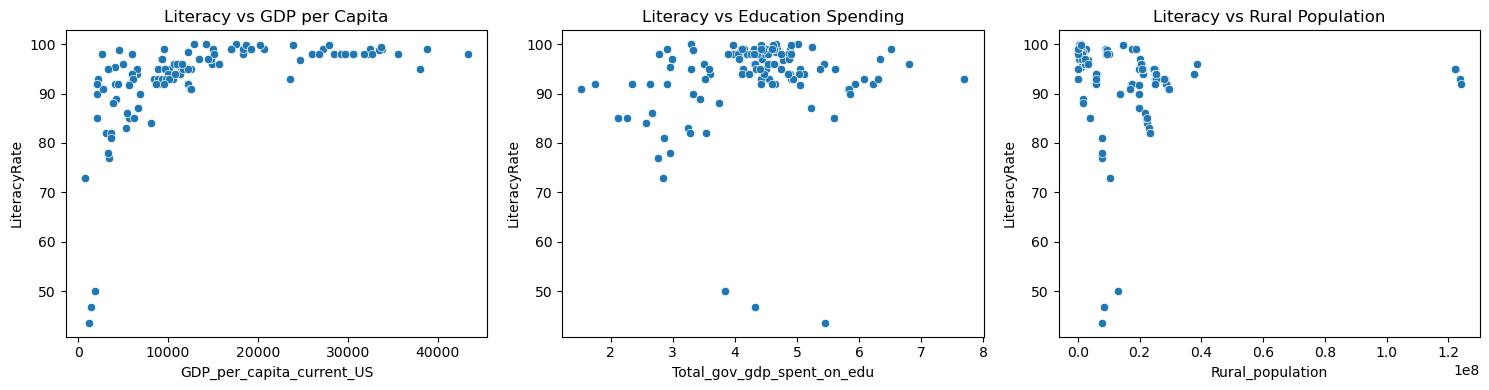

In [7]:
# --- Scatter Plots for Key Predictors ---
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='GDP_per_capita_current_US', y='LiteracyRate')
plt.title('Literacy vs GDP per Capita')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Total_gov_gdp_spent_on_edu', y='LiteracyRate')
plt.title('Literacy vs Education Spending')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Rural_population', y='LiteracyRate')
plt.title('Literacy vs Rural Population')

plt.tight_layout()
plt.show()

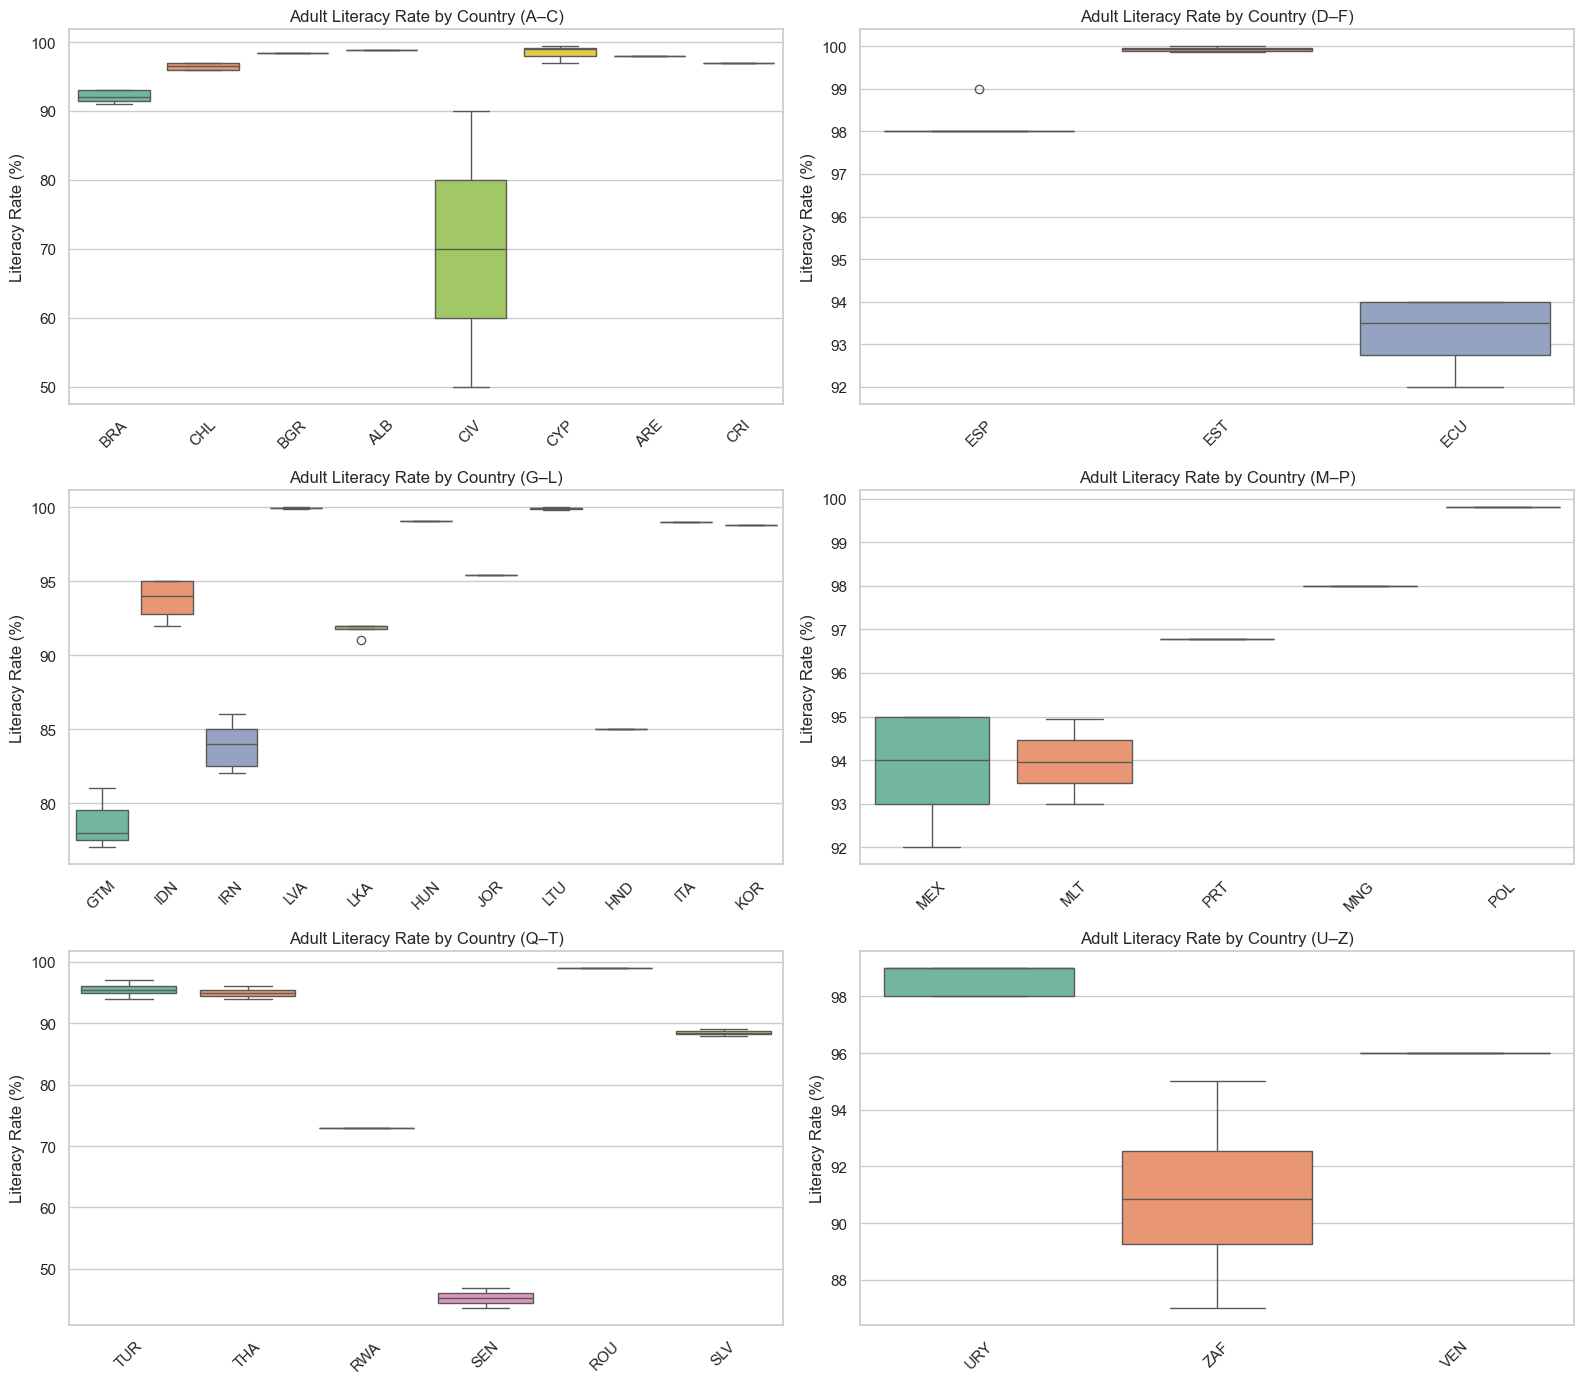

In [41]:
# Set the plot style
sns.set(style="whitegrid")

# Define alphabetical ranges
groups = {
    'A–C': ('A', 'C'),
    'D–F': ('D', 'F'),
    'G–L': ('G', 'L'),
    'M–P': ('M', 'P'),
    'Q–T': ('Q', 'T'),
    'U–Z': ('U', 'Z')
}

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
axes = axes.flatten()

# Plot each group
for i, (label, (start, end)) in enumerate(groups.items()):
    # Filter countries in the alphabetical range
    subset = df[df['Country'].str[0].between(start, end)]
    
    sns.boxplot(data=subset, x='Country', y='LiteracyRate', hue='Country', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Adult Literacy Rate by Country ({label})', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Literacy Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [51]:
# Top five countries that had improving literacy rates

# Get earliest and latest literacy rates for each country
earliest = df.sort_values('year').groupby('Country').first().reset_index()
latest = df.sort_values('year').groupby('Country').last().reset_index()

# Merge to compute difference
merged = pd.merge(earliest[['Country', 'LiteracyRate']], latest[['Country', 'LiteracyRate']], on='Country', suffixes=('_earliest', '_latest'))

# Calculate improvement
merged['Improvement'] = merged['LiteracyRate_latest'] - merged['LiteracyRate_earliest']

# Sort and show top 10
top10_improved = merged.sort_values('Improvement', ascending=False).head(10)
print(top10_improved[['Country', 'LiteracyRate_earliest', 'LiteracyRate_latest', 'Improvement']])

   Country  LiteracyRate_earliest  LiteracyRate_latest  Improvement
5      CIV               50.03968             90.00000     39.96032
15     IRN               82.00000             86.00000      4.00000
29     SEN               43.59273             46.83367      3.24094
11     GTM               78.00000             81.00000      3.00000
22     MEX               92.00000             95.00000      3.00000
14     IDN               92.00000             95.00000      3.00000
32     TUR               94.00000             97.00000      3.00000
7      CYP               97.00000             99.36000      2.36000
3      BRA               91.00000             93.00000      2.00000
8      ECU               92.00000             94.00000      2.00000


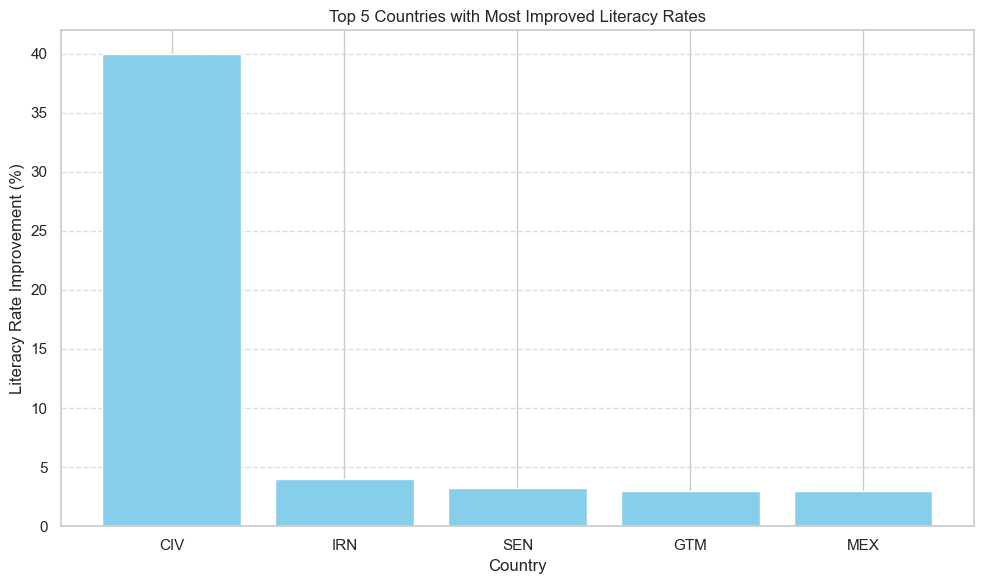

In [47]:
# Bar plot of top 5 countries with improvement
plt.figure(figsize=(10, 6))
plt.bar(top5_improved['Country'], top5_improved['Improvement'], color='skyblue')
plt.title('Top 5 Countries with Most Improved Literacy Rates')
plt.xlabel('Country')
plt.ylabel('Literacy Rate Improvement (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

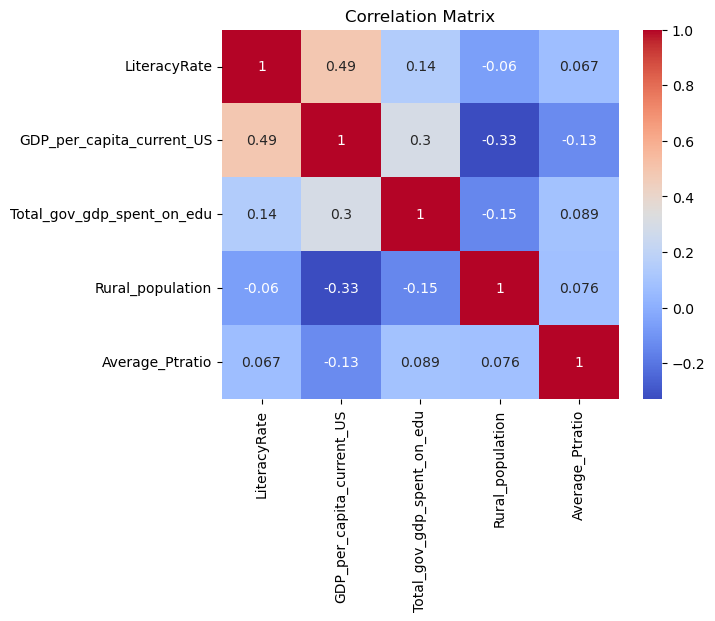

In [8]:
correlation_matrix = df[[
    'LiteracyRate',
    'GDP_per_capita_current_US',
    'Total_gov_gdp_spent_on_edu',
    'Rural_population',
    'Average_Ptratio'
]].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [9]:
# Drop rows with missing regression predictors
df_reg = df.dropna(subset=[
    'GDP_per_capita_current_US',
    'Total_gov_gdp_spent_on_edu',
    'Rural_population',
    'Average_Ptratio'
])

X = df_reg[[
    'GDP_per_capita_current_US',
    'Total_gov_gdp_spent_on_edu',
    'Rural_population',
    'Average_Ptratio'
]]
y = df_reg['LiteracyRate']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           LiteracyRate   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     10.33
Date:                Fri, 30 May 2025   Prob (F-statistic):           3.61e-07
Time:                        09:26:40   Log-Likelihood:                -409.85
No. Observations:                 118   AIC:                             829.7
Df Residuals:                     113   BIC:                             843.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [25]:
# Define binary target: High Literacy = 1 if LiteracyRate >= 90%
df_log = df_reg.copy()
df_log['HighLiteracy'] = (df_log['LiteracyRate'] >= 90).astype(int)

X_log = df_log[[
    'GDP_per_capita_current_US',
    'Total_gov_gdp_spent_on_edu',
    'Rural_population',
    'Average_Ptratio'
]]
y_log = df_log['HighLiteracy']

X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.3, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[ 0  9]
 [ 0 27]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.75      1.00      0.86        27

    accuracy                           0.75        36
   macro avg       0.38      0.50      0.43        36
weighted avg       0.56      0.75      0.64        36



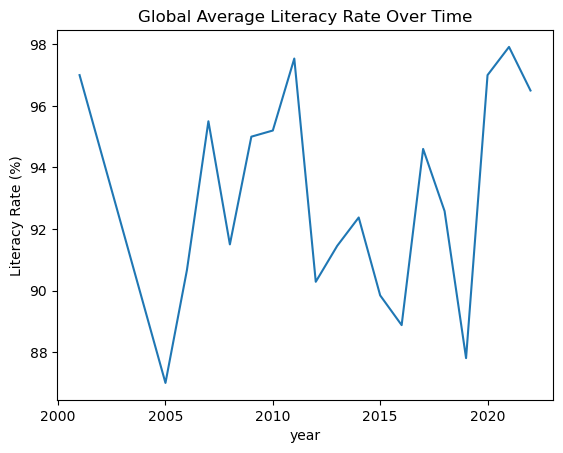

In [23]:
# Mean Literacy Rate Over Time
time_trend = df.groupby('year')['LiteracyRate'].mean().reset_index()
sns.lineplot(data=time_trend, x='year', y='LiteracyRate')
plt.title('Global Average Literacy Rate Over Time')
plt.ylabel('Literacy Rate (%)')
plt.show()